# Trabalho 03 — Reconhecimento de Letras usando Perceptrons

**Disciplina:** Redes Neurais Artificiais

Dois classificadores baseados em **Perceptron** (Rosenblatt) capazes de reconhecer duas letras — **X** e **T** — representadas como imagens binárias em uma grade $5\times5$:

- **(a)** um único neurônio, com saída bipolar única ($+1$ = X, $-1$ = T);
- **(b)** uma camada com **dois neurônios**, cada um "especialista" em reconhecer uma das letras.

A ideia é mostrar, de forma simples, como a regra de aprendizado do perceptron ajusta os pesos até separar corretamente as duas classes, o que esses pesos "aprendem" sobre as letras, e o quanto o modelo tolera ruído (pixels trocados) nos padrões de entrada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# reprodutibilidade dos experimentos com ruído (mais à frente)
RNG = np.random.default_rng(42)

plt.rcParams["figure.dpi"] = 110

## 1. Os padrões de entrada

Cada letra é desenhada em uma grade $5\times5$ (25 pixels). Um pixel **aceso** vale $+1$ e um pixel **apagado** vale $-1$ — essa é a chamada codificação **bipolar**, preferível à binária $\{0,1\}$ porque facilita a regra de aprendizado (veja a Seção 2).

A grade é "achatada" (*flatten*) em um vetor de 25 posições, varrendo linha a linha, que passa a ser a entrada $\mathbf{x} = (x_1, \dots, x_{25})$ do perceptron.

In [2]:
X_GRID = np.array([
    [ 1, -1, -1, -1,  1],
    [-1,  1, -1,  1, -1],
    [-1, -1,  1, -1, -1],
    [-1,  1, -1,  1, -1],
    [ 1, -1, -1, -1,  1],
], dtype=float)

T_GRID = np.array([
    [ 1,  1,  1,  1,  1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
], dtype=float)

N_LIN, N_COL = X_GRID.shape
N_ENTRADAS = N_LIN * N_COL  # 25

x_X = X_GRID.flatten()
x_T = T_GRID.flatten()

PADROES = np.array([x_X, x_T])       # shape (2, 25)
NOMES_PADROES = ["X", "T"]

print("Vetor da letra X (25 posições):\n", x_X.astype(int))
print("\nVetor da letra T (25 posições):\n", x_T.astype(int))

Vetor da letra X (25 posições):
 [ 1 -1 -1 -1  1 -1  1 -1  1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1  1 -1 -1 -1
  1]

Vetor da letra T (25 posições):
 [ 1  1  1  1  1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1
 -1]


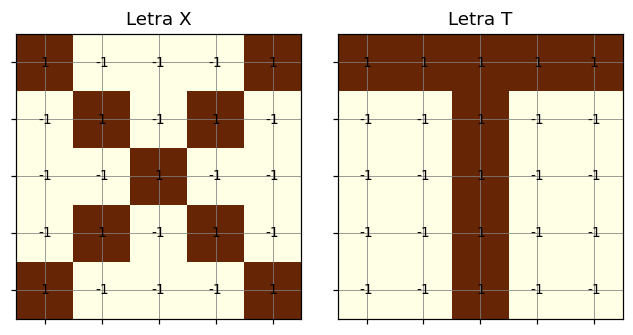

In [3]:
def plot_padroes(grids, nomes, cmap="YlOrBr"):
    fig, axs = plt.subplots(1, len(grids), figsize=(3 * len(grids), 3))
    if len(grids) == 1:
        axs = [axs]
    for ax, grid, nome in zip(axs, grids, nomes):
        ax.imshow(grid, cmap=cmap, vmin=-1, vmax=1)
        ax.set_title(f"Letra {nome}")
        ax.set_xticks(range(grid.shape[1])); ax.set_yticks(range(grid.shape[0]))
        ax.set_xticklabels([]); ax.set_yticklabels([])
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                ax.text(j, i, int(grid[i, j]), ha="center", va="center", fontsize=9)
        ax.grid(color="gray", linewidth=0.5)
    fig.tight_layout()
    return fig

_ = plot_padroes([X_GRID, T_GRID], NOMES_PADROES)
plt.show()

## 2. Fundamentação teórica: o Perceptron

Um perceptron simples calcula uma **combinação linear** das entradas e aplica uma função de ativação:

$$
\text{net} = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}\cdot\mathbf{x} + b,
\qquad
y = f(\text{net})
$$

onde $x_i$ são os pixels da imagem, $w_i$ os pesos sinápticos, $b$ o *bias* (limiar) e $f(\cdot)$ a função de ativação. Como as classes aqui são $-1$ e $+1$, usamos a **função degrau bipolar**:

$$
f(\text{net}) =
\begin{cases}
+1, & \text{net} \ge 0\\
-1, & \text{net} < 0
\end{cases}
$$

Geometricamente, $\mathbf{w}\cdot\mathbf{x}+b=0$ define um **hiperplano** no espaço de 25 dimensões. O perceptron separa corretamente as duas classes se, e somente se, elas forem **linearmente separáveis** — o que é sempre verdade quando há apenas dois padrões distintos, como neste trabalho.

### 2.1 Regra de aprendizado de Rosenblatt

Os pesos são ajustados **padrão a padrão**, pela regra:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta\,(t - y)\,\mathbf{x},
\qquad
b \leftarrow b + \eta\,(t-y)
$$

em que $t \in \{-1,+1\}$ é a saída desejada (alvo), $y$ é a saída atual do neurônio e $\eta>0$ é a taxa de aprendizado. Se $y=t$, nada muda; se houver erro, $(t-y)=\pm2$ e os pesos se deslocam na direção que corrige aquele erro. O **Teorema de Convergência do Perceptron** garante que, para classes linearmente separáveis, esse processo converge em um número finito de épocas.

In [4]:
def ativacao_bipolar(net):
    '''Função degrau bipolar: +1 se net >= 0, -1 caso contrário.'''
    return np.where(net >= 0, 1.0, -1.0)


class Perceptron:
    '''Perceptron simples (1 neurônio), ativação bipolar (+1/-1),
    treinado pela regra de Rosenblatt.'''

    def __init__(self, n_entradas, eta=1.0):
        # pesos e bias iniciados em zero (inicialização clássica)
        self.w = np.zeros(n_entradas)
        self.b = 0.0
        self.eta = eta
        self.historico_erros = []  # nº de padrões mal classificados por época

    def net(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return ativacao_bipolar(self.net(X))

    def fit(self, X, t, max_epocas=100):
        for _ in range(max_epocas):
            erros = 0
            for xi, ti in zip(X, t):
                yi = self.predict(xi.reshape(1, -1))[0]
                if yi != ti:
                    erro = (ti - yi)
                    self.w += self.eta * erro * xi
                    self.b += self.eta * erro
                    erros += 1
            self.historico_erros.append(erros)
            if erros == 0:
                break
        return self

## 3. Item (a) — Perceptron de 1 neurônio

Aqui um único neurônio decide entre as duas letras: o alvo é $t=+1$ para a letra **X** e $t=-1$ para a letra **T**.

In [5]:
ALVOS_A = np.array([1.0, -1.0])  # X -> +1 , T -> -1

perceptron_a = Perceptron(N_ENTRADAS, eta=1.0)
perceptron_a.fit(PADROES, ALVOS_A, max_epocas=100)

print(f"Convergiu em {len(perceptron_a.historico_erros)} época(s).")
print("Erros por época:", perceptron_a.historico_erros)
print("\nPesos finais (w):\n", np.round(perceptron_a.w, 2))
print("\nBias final (b):", perceptron_a.b)

for x, nome, alvo in zip(PADROES, NOMES_PADROES, ALVOS_A):
    y = perceptron_a.predict(x.reshape(1, -1))[0]
    print(f"Letra {nome}: saída y = {y:+.0f}   (alvo = {alvo:+.0f})  {'OK' if y==alvo else 'ERRO'}")

Convergiu em 3 época(s).
Erros por época: [1, 1, 0]

Pesos finais (w):
 [ 0. -4. -4. -4.  0.  0.  4. -4.  4.  0.  0.  0.  0.  0.  0.  0.  4. -4.
  4.  0.  4.  0. -4.  0.  4.]

Bias final (b): 0.0
Letra X: saída y = +1   (alvo = +1)  OK
Letra T: saída y = -1   (alvo = -1)  OK


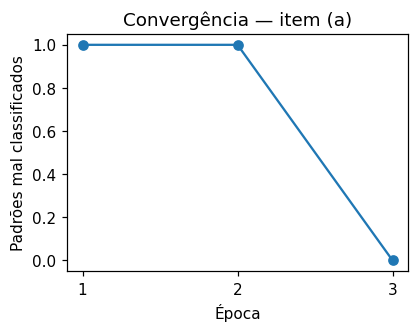

In [6]:
fig, ax = plt.subplots(figsize=(4, 2.8))
h = perceptron_a.historico_erros
ax.plot(range(1, len(h) + 1), h, marker="o")
ax.set_xlabel("Época"); ax.set_ylabel("Padrões mal classificados")
ax.set_title("Convergência — item (a)")
ax.set_xticks(range(1, len(h) + 1))
plt.show()

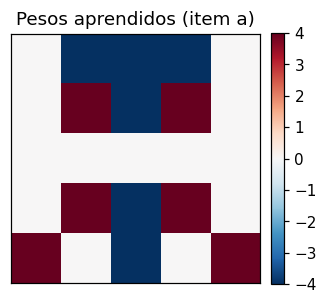

In [7]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
grid_w = perceptron_a.w.reshape(N_LIN, N_COL)
vlim = np.max(np.abs(grid_w))
im = ax.imshow(grid_w, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
ax.set_title("Pesos aprendidos (item a)")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

**Interpretação:** os pesos só ficam diferentes de zero exatamente nos pixels que **diferenciam** X de T — a diagonal do X e a haste vertical do T. Os pixels que são iguais nas duas letras (as bordas em branco) recebem peso zero, pois nunca influenciaram uma correção de erro. Ou seja: com apenas dois exemplos, o perceptron aprendeu sozinho *quais pixels realmente importam* para separar as duas letras.

## 4. Item (b) — Camada com 2 neurônios

Para discriminar $K$ classes é comum usar uma camada com $K$ neurônios de saída — cada um treinado para responder $+1$ à sua própria classe e $-1$ às demais (codificação "um-contra-todos"). Sem camada oculta, cada neurônio $k$ tem seu próprio vetor de pesos $\mathbf{w}_k$ e bias $b_k$, treinado de forma **independente** pela mesma regra da Seção 2.1, usando apenas a coluna de alvos correspondente.

Aqui: dois neurônios, com saída desejada $(y_1,y_2) = (+1,-1)$ para a letra X e $(y_1,y_2) = (-1,+1)$ para a letra T.

In [8]:
class CamadaPerceptrons:
    '''Camada de M perceptrons independentes (sem camada oculta).'''

    def __init__(self, n_entradas, n_saidas, eta=1.0):
        self.neuronios = [Perceptron(n_entradas, eta=eta) for _ in range(n_saidas)]

    def predict(self, X):
        saidas = [n.predict(X) for n in self.neuronios]
        return np.stack(saidas, axis=-1)

    def fit(self, X, T, max_epocas=100):
        for k, neuronio in enumerate(self.neuronios):
            neuronio.fit(X, T[:, k], max_epocas=max_epocas)
        return self


ALVOS_B = np.array([
    [1.0, -1.0],   # letra X -> (y1=+1, y2=-1)
    [-1.0, 1.0],   # letra T -> (y1=-1, y2=+1)
])

camada_b = CamadaPerceptrons(N_ENTRADAS, n_saidas=2, eta=1.0)
camada_b.fit(PADROES, ALVOS_B, max_epocas=100)

for k, n in enumerate(camada_b.neuronios, start=1):
    print(f"Neurônio {k}: convergiu em {len(n.historico_erros)} época(s); "
          f"erros por época = {n.historico_erros}")

for x, nome, alvo in zip(PADROES, NOMES_PADROES, ALVOS_B):
    y = camada_b.predict(x.reshape(1, -1))[0]
    y1, y2 = y
    a1, a2 = alvo
    print(f"Letra {nome}: saída (y1,y2) = ({y1:+.0f}, {y2:+.0f})   "
          f"(alvo = ({a1:+.0f}, {a2:+.0f}))  "
          f"{'OK' if np.array_equal(y, alvo) else 'ERRO'}")

Neurônio 1: convergiu em 3 época(s); erros por época = [1, 1, 0]
Neurônio 2: convergiu em 2 época(s); erros por época = [2, 0]
Letra X: saída (y1,y2) = (+1, -1)   (alvo = (+1, -1))  OK
Letra T: saída (y1,y2) = (-1, +1)   (alvo = (-1, +1))  OK


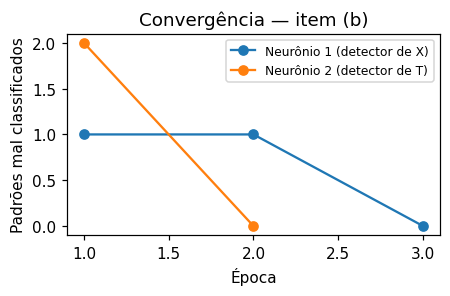

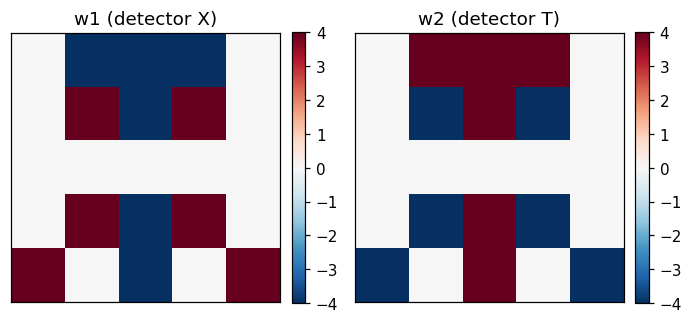

w1 == pesos do item (a)? True
w2 == -w1? True


In [9]:
fig, ax = plt.subplots(figsize=(4.2, 2.8))
rotulos = ["Neurônio 1 (detector de X)", "Neurônio 2 (detector de T)"]
for n, r in zip(camada_b.neuronios, rotulos):
    h = n.historico_erros
    ax.plot(range(1, len(h) + 1), h, marker="o", label=r)
ax.set_xlabel("Época"); ax.set_ylabel("Padrões mal classificados")
ax.set_title("Convergência — item (b)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

vlim = max(np.max(np.abs(n.w)) for n in camada_b.neuronios)
grids_w = [n.w.reshape(N_LIN, N_COL) for n in camada_b.neuronios]

fig, axs = plt.subplots(1, 2, figsize=(6.4, 3.2))
for ax, grid, titulo in zip(axs, grids_w, ["w1 (detector X)", "w2 (detector T)"]):
    im = ax.imshow(grid, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
    ax.set_title(titulo); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

print("w1 == pesos do item (a)?", np.allclose(camada_b.neuronios[0].w, perceptron_a.w))
print("w2 == -w1?", np.allclose(camada_b.neuronios[1].w, -camada_b.neuronios[0].w))

**Interpretação:** como o neurônio 1 tem exatamente o mesmo alvo do perceptron do item (a) ($+1$ para X, $-1$ para T), ele aprende os **mesmos pesos**. Como o alvo do neurônio 2 é o oposto, seus pesos saem $\mathbf{w}_2 = -\mathbf{w}_1$. Para este problema com apenas 2 classes, a camada de 2 neurônios é redundante em relação ao item (a) — mas essa estrutura é a que generaliza para problemas com **mais de duas letras**, onde um único neurônio bipolar não seria suficiente.

## 5. Robustez a ruído

Para avaliar a generalização, cada letra é corrompida invertendo (`flip`) de 1 a 8 pixels aleatórios, e reclassificada pelos dois modelos treinados. Repetimos o experimento várias vezes por nível de ruído para estimar a taxa de acerto.

In [10]:
def aplicar_ruido(x, n_flips, rng):
    x_ruidoso = x.copy()
    idx = rng.choice(len(x), size=n_flips, replace=False)
    x_ruidoso[idx] *= -1
    return x_ruidoso


def testar_robustez(predict_fn, alvos, n_ensaios=300, max_flips=8):
    taxas = []
    for n_flips in range(0, max_flips + 1):
        acertos, total = 0, 0
        for x_original, alvo in zip(PADROES, alvos):
            for _ in range(n_ensaios):
                x_ruido = aplicar_ruido(x_original, n_flips, RNG) if n_flips > 0 else x_original
                y = predict_fn(x_ruido.reshape(1, -1))[0]
                acertos += int(np.array_equal(y, alvo))
                total += 1
        taxas.append(acertos / total)
    return np.array(taxas)


taxas_a = testar_robustez(perceptron_a.predict, ALVOS_A)
taxas_b = testar_robustez(camada_b.predict, ALVOS_B)

print(f"{'pixels invertidos':>18} | {'acerto item (a)':>16} | {'acerto item (b)':>16}")
for k in range(len(taxas_a)):
    print(f"{k:>18} | {taxas_a[k]*100:15.1f}% | {taxas_b[k]*100:15.1f}%")

 pixels invertidos |  acerto item (a) |  acerto item (b)
                 0 |           100.0% |           100.0%
                 1 |           100.0% |           100.0%
                 2 |           100.0% |           100.0%
                 3 |           100.0% |           100.0%
                 4 |           100.0% |           100.0%
                 5 |           100.0% |           100.0%
                 6 |            99.8% |            99.2%
                 7 |            98.2% |            97.2%
                 8 |            95.3% |            93.2%


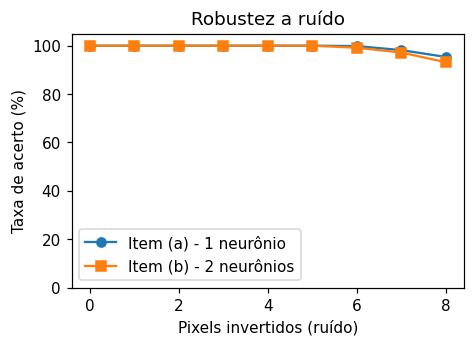

In [11]:
fig, ax = plt.subplots(figsize=(4.6, 3))
flips = range(len(taxas_a))
ax.plot(flips, taxas_a * 100, marker="o", label="Item (a) - 1 neurônio")
ax.plot(flips, taxas_b * 100, marker="s", label="Item (b) - 2 neurônios")
ax.set_xlabel("Pixels invertidos (ruído)")
ax.set_ylabel("Taxa de acerto (%)")
ax.set_title("Robustez a ruído")
ax.set_ylim(0, 105)
ax.legend()
plt.show()

## 6. Conclusão

Os dois perceptrons resolvem o problema de reconhecer as letras X e T, pois o conjunto de treinamento com apenas dois padrões é trivialmente linearmente separável, satisfazendo o Teorema de Convergência do Perceptron. O item (b), com dois neurônios independentes, é equivalente em capacidade ao item (a) para este problema binário — a única diferença é a codificação da saída (um bit bipolar vs. dois bits redundantes) — mas generaliza melhor a estrutura para problemas com mais de duas classes.

A análise dos pesos mostrou que o perceptron identifica automaticamente, apenas pela regra de correção de erro, os pixels realmente discriminantes entre as duas letras; e o teste de ruído confirmou que essa solução é robusta a pequenas distorções nos padrões de entrada (100% de acerto até 5 de 25 pixels invertidos, degradando suavemente depois disso).